## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





[   10   211   413   615   817  1019  1221  1423  1625  1827  2029  2231
  2433  2634  2836  3038  3240  3442  3644  3846  4048  4250  4452  4654
  4856  5057  5259  5461  5663  5865  6067  6269  6471  6673  6875  7077
  7279  7481  7682  7884  8086  8288  8490  8692  8894  9096  9298  9500
  9702  9904 10105 10307 10509 10711 10913 11115 11317 11519 11721 11923
 12125 12327 12528 12730 12932 13134 13336 13538 13740 13942 14144 14346
 14548 14750 14952 15153 15355 15557 15759 15961 16163 16365 16567 16769
 16971 17173 17375 17576 17778 17980 18182 18384 18586 18788 18990 19192
 19394 19596 19798 20000]
[np.float64(50.0), np.float64(47.39336492890995), np.float64(44.55205811138014), np.float64(51.38211382113821), np.float64(50.673194614443084), np.float64(49.656526005888125), np.float64(50.532350532350534), np.float64(51.58116654954322), np.float64(50.338461538461544), np.float64(52.59989053092501), np.float64(48.693937900443565), np.float64(48.94666069027342), np.float64(50.34936292642

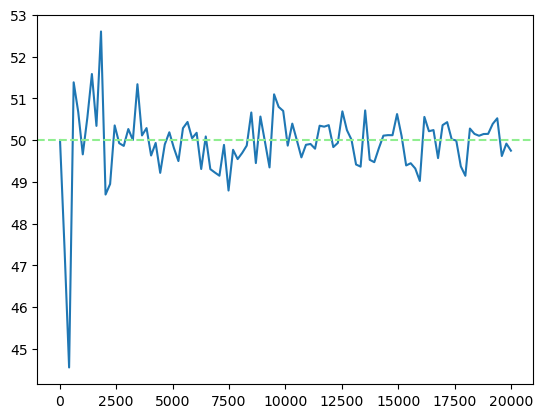

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vec_prob = [1/2,1/2]

def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return (sum(campione)/n)*100

funzione(vec_prob, 10)

array = np.linspace(10,20000,100, dtype=int) #genero array casuale con numeri tra 10 a 20000 in modo che vengano 100 elementi
print(array)
vec_return = []
for elem in array:
    campione = funzione(vec_prob, elem)
    vec_return.append(campione)

print (vec_return)

plt.plot(array, vec_return)
plt.axhline(50, color = 'lightgreen', linestyle = '--')



## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [ ]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape #mi riporta il numero di righe e colonne


(891, 12)

In [ ]:
df.isnull().sum() # conto i valoti mancanti

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
df['Embarked'].mode() # questo mi da l'indice 0 e il valore più frequente S
most_common = df['Embarked'].mode() [0] #metto indice e mi da valore più frequente

df['Embarked'] = df['Embarked'].fillna(most_common) #.fillna() riempie gli na con quello che gli metto dentro la funzione, poi riassegno la colonna e salvo
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [ ]:
df.duplicated().sum() #controllo se ci sono duplicati e sommo (perchè .duplicated() riotrna una boolmask)

np.int64(0)

In [ ]:
#  Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio

eta_media = df['Age'].mean()
df['Age'] = df['Age'].fillna(eta_media)
df.groupby('Pclass')['Age'].mean()

Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

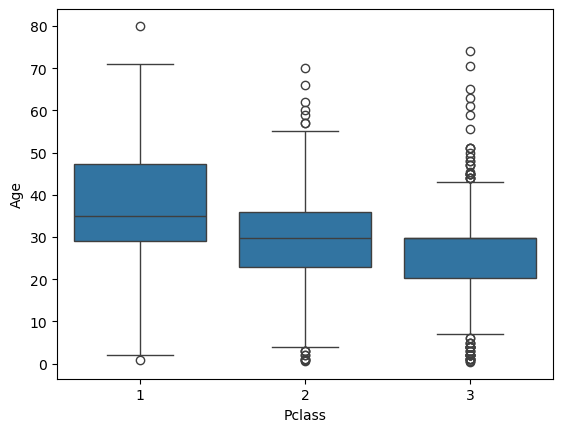

In [ ]:
# - Visualizza la distribuzione dell'età per classe
sns.boxplot(df, x = 'Pclass', y = 'Age')

<Axes: xlabel='Pclass', ylabel='Age'>

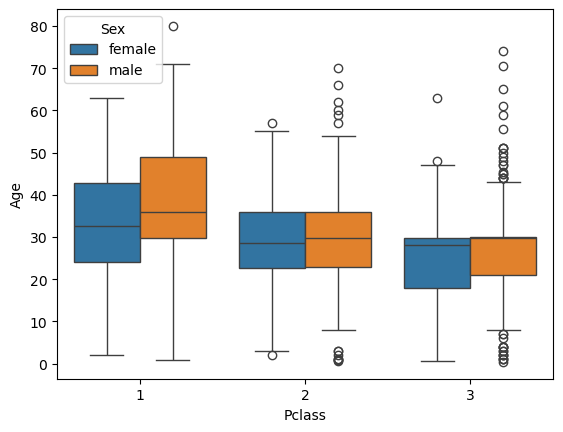

In [ ]:
# - Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(df, x = 'Pclass', y = 'Age', hue='Sex') #divide i dati nelle categorie che trova

 ## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()